# 🧪 LAB: Non-linear Dimensionality Reduction — t-SNE and UMAP

Over the past few weeks, we have explored how to handle non-linear relationships, mainly in the context of classification and regression tasks.

However, sometimes the first and most important step is to **visualize** the data — to gain intuition, spot structure, or detect outliers — even before any predictive modeling. You have already seen how PCA can help with this, but as we discussed this week, (ordinary) PCA is a linear method and may not capture non-linear patterns in the data effectively.

In this lab, you will learn about two popular **non-linear dimensionality reduction techniques** that are typically used for **data visualization**:  
- **t-SNE (t-distributed Stochastic Neighbor Embedding)**  
- **UMAP (Uniform Manifold Approximation and Projection)**

You will apply and compare these methods on two datasets:
- A simple biological dataset: Palmer Penguins
- A high-dimensional human genotype dataset from the 1000 Genomes Project (adapted from Diaz-Papkovich *et al.*, 2019)

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [33]:
NAMEs = "Laine Goldmacher, Max Magrill, Ashley Qin"

## 1. Background Reading (20 points)

Begin by reading **Section 5.3: t-SNE and UMAP for High-Dimensional Data** from the [*Machine Learning Hero* book](https://www.oreilly.com/library/view/machine-learning-hero/9781837025015/), which is available through UVA’s subscription to O’Reilly.

After reading, discuss with your group and respond to the following questions:

a. **Why might we choose t-SNE or UMAP over PCA for dimensionality reduction?**  
Briefly explain the limitations of PCA, and why non-linear methods like t-SNE and UMAP can be more effective in some contexts.

b. **Summarize the strengths and weaknesses of t-SNE and UMAP.**  
What are the key differences between the two methods? In what situations might you prefer one over the other?

c. **What are the main hyperparameters of each method, and what role do they play?**  
Describe how these hyperparameters affect the behavior and output of the algorithms.


a. 
- PCA is a linear dimensionality reduction technique, so it may fail to capture complex nonlinear relationships in high-dimensional data. This limitation can be combatted by more sophisticated techniques like t-SNE or UMAP. 
- These are two advanced non-linear dimensionality reduction techniques. t-SNE and UMAP methods are designed to map high-dimensional data into a lower-dimensional spaces, usually two or three dimensions.
- They are particularly useful for visualization because they can reveal clusters, local neighborhoods, and nonlinear structures that PCA may not capture.


b. 
- t-SNE (t-Distributed Stochastic Neighbor Embedding) Strengths:
  - A sophisticated non-linear dimensionality reduction technique that is great for visualizing high-dimensional datasets. 
  - Excels at preserving the local structure of the data, making it especially valuable for complex datasets with non-linear relationships.
  - Excels at capturing and representing complex, non-linear relationships within high-dimensional data.
    - Reveals intricate patterns, clusters, and structures that linear dimensionality reduction methods might overlook.
    - Great for visualizing and analyzing datasets in fields where underlying relationships are often non-linear and multifaceted.
  - Excels at maintaining relative distances between nearby points in a high-dimensional space when mapping them to a lower-dimensional space. 
    - Helps when identifying clusters and patterns in the data that might not be apparent in the original high-dimensional representation.
  - t-SNE is primarily used to create 2D or 3D representations of high-dimensional data, making it great for EDA.
    - Helps visualize complex, multi-dimensional datasets in a more interpretable form.
    - Great for image recognition, natural language processing, and bioinformatics.
- t-SNE Weaknesses:
  - Computational complexity: t-SNE's algorithm has a time complexity of O(n^2), where n is the number of data points. 
    - Processing times can extend to hours or even days for extensive datasets.
  - Stochastic nature: The algorithm employs random initializations and sampling techniques, which introduce an element of randomness into the process.
    - Multiple runs of t-SNE on the same dataset may yield slightly different results, which is bad for reproducibility. 
  - Local structure emphasis: While t-SNE excels at preserving local neighborhood relationships, it may not accurately represent the global structure of the data. 
    - Users should be cautious when drawing conclusions about overall data structure solely based on t-SNE visualizations.
- UMAP Strengths:
  - A powerful non-linear dimensionality reduction technique.
  - Fast and scalable alternative to t-SNE.
  - Excels at preserving both local and global structure more effectively than t-SNE. 
    - Can maintain relationships between data points at different scales, providing a more accurate representation of the original high-dimensional data.
    - Like t-SNE, UMAP is great for preserving local relationships between data points.
    - Unlike t-SNE, which primarily focuses on local structure, UMAP also does a better job of preserving the global structure of the data.
    - The improved preservation of both local and global structure makes UMAP particularly useful for tasks such as clustering, anomaly detection, and exploratory data analysis. 
    - It can reveal patterns and relationships in the data that might be missed by techniques that focus solely on local or global structure.
  - Demonstrates superior computational efficiency compared to t-SNE, making it particularly well-suited for analyzing larger datasets.
    - Better scalability, faster processing, memory efficiency, parallelization, preservation of global structure. 
  - UMAP demonstrates exceptional adaptability across various data types, making it a powerful tool for diverse applications
    - Good for numerical data, categorical data, mixed data types, text data, image data, and graph-structured data. 
  - UMAP is built on a solid mathematical foundation, drawing from concepts in topological data analysis and manifold learning.
    - Theoretical grounding provides a robust basis for performance and interpretability. 
- UMAP Weaknesses:
  - Like t-SNE, results may depend on hyperparameter choices and random initialization.
  - The appearance of clusters/distances in the low-dimensional embedding should not automatically be interpreted as exact relationships in the original data.
  - Parameters such as n_neighbors and min_dist can substantially change the resulting visualization.
  - Although UMAP generally preserves more global structure than t-SNE, it still introduces distortion when reducing high-dimensional data.
- t-SNE vs. UMAP: 
  - I would prefer t-SNE when my primary goal is visualizing detailed local clusters in a relatively small or moderate-sized dataset. 
  - I would prefer UMAP for larger datasets where computational efficiency is important, or when I want to preserve both the local neighborhoods and the overall global structure of the data.

c. 

- t-SNE has multiple important parameters including n_components, random_state, perplexity, and n_iter. 
  - The n_components parameter defines the number of dimensions in the embedding space, with a value of 2 or 3 often used for visualization. 
  - The random_state parameter is used to initialize the model with a random seed, making the results reproducible. 
  - The perplexity parameter is used to control the number of neighbors to consider when consolidating the data, with larger data need a higher perplexity. 
  - The n_iter parameter is used to set the number of iterations for this optimization.

- UMAP has two main important parameters, including n_neighbors and min_dist. 
  - N_neighbors allows UMAP to consider more or fewer nearby points as neighbors, which can preserve more of the global data structure. 
  - Min_dist controls the minimum distance between points in the low-dimensional space, controlling how compactly data can be placed together. 

## 2. Experiment with the Palmer Penguins Dataset (Toy Example) (50 points)

To get hands-on experience, you will begin by applying dimensionality reduction techniques to a small and interpretable dataset: Palmer Penguins.

Before you begin coding, read the official documentation for the following methods:

- [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) — from `sklearn.decomposition`
- [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) — from `sklearn.manifold`
- [UMAP](https://umap-learn.readthedocs.io/en/latest/basic_usage.html) — from the `umap-learn` package

After reviewing the documentation, complete the following tasks:

a. Load the Palmer Penguins dataset as demonstrated in the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/basic_usage.html#penguin-data).  

Select the following numerical features:

- `bill_length_mm`  
- `bill_depth_mm`  
- `flipper_length_mm`  
- `body_mass_g`

Then, **standardize** these features so that each has zero mean and unit variance.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

penguins = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [35]:
penguins = penguins.dropna()
y = penguins['species']

penguin_data = penguins[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
    ]
].values

scaled_penguin_data = StandardScaler().fit_transform(penguin_data)

b. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the selected features to **2 dimensions**.

Then, for each method:
- Create a **scatter plot** of the 2D projection.
- Use a different color to represent each **species** in the dataset.

This will help you visually assess how well each method separates the species in the reduced space.

*N.B.* You may need to first install `UMAP-learn`. Follow the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html) for that.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


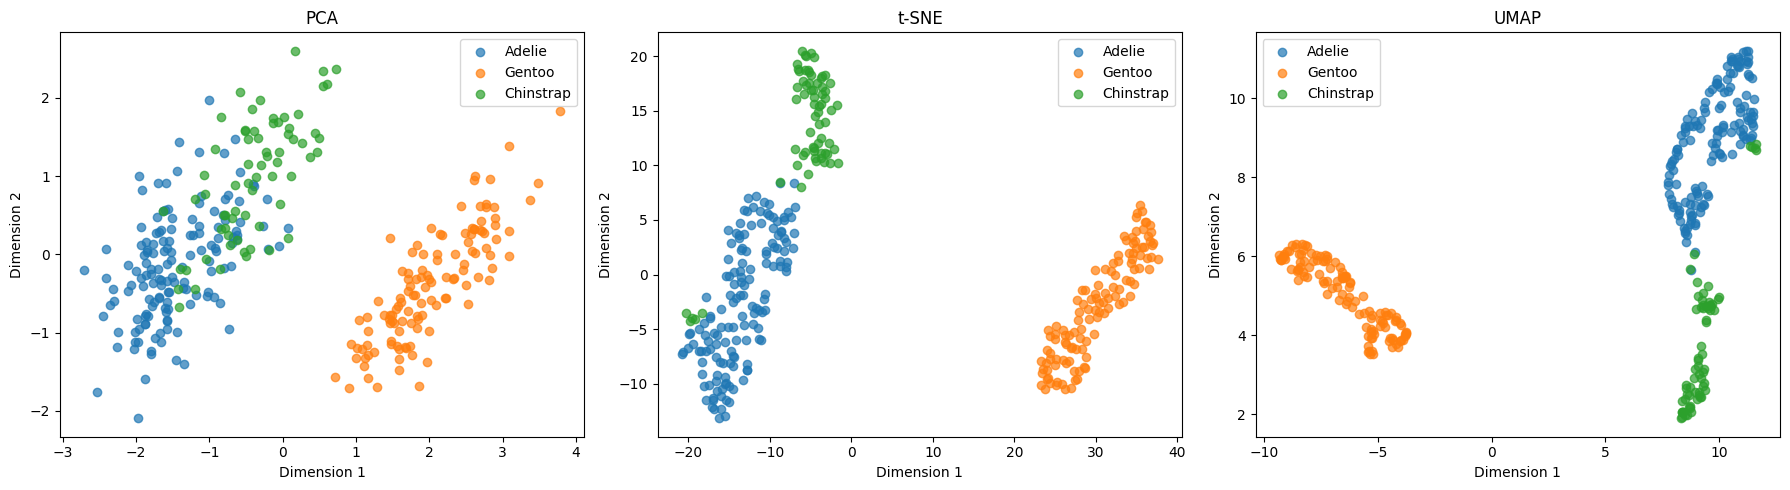

In [36]:
# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_penguin_data)

#tSNE
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(scaled_penguin_data)

# UMAP
umap_model = UMAP(n_components=2, random_state=42)
umap_data = umap_model.fit_transform(scaled_penguin_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

projections = [pca_data, tsne_data, umap_data]
titles = ['PCA', 't-SNE', 'UMAP']

for ax, projection, title in zip(axes, projections, titles):
    for species in y.unique():
        mask = y == species
        
        ax.scatter(
            projection[mask, 0],
            projection[mask, 1],
            label=species,
            alpha=0.7
        )
    
    ax.set_title(title)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.legend()

plt.tight_layout()
plt.show()

c. Analyze the resulting plots and describe the main patterns you observe.

- Which method produces the most visually separable clusters?
- Are there any species that overlap in one method but not in others?
- What might explain these differences in how the data is projected?

Elaborate on your observations and compare the strengths and limitations of each method based on this toy example.


- All three methods reveal differences among the three penguin species, but the amount of separation varies considerably. UMAP produces the most visually separable clusters overall. Gentoo forms a completely distinct cluster on the left, while Adelie and Chinstrap are primarily separated into different regions on the right. There are only a few observations near the boundary between Adelie and Chinstrap. t-SNE has a similar separation, but has a bit more overlap between Adelie and Chinstrap. These two methods, however, show 3 pretty distinct clusters, while PCA seems to only really show 2 clusters. 

- Adelie and Chinstrap are extremely overlapped in PCA, while UMAP and t-SNE do a much better job setting them apart. This indicates that the first two principal components do not completely distinguish these species.


- These differences result from how each method constructs the projection:
  - PCA is linear and chooses directions that maximize overall variance in the predictors without considering species labels. Therefore, directions that contain the most variation are not necessarily those that best separate species. 
  - In contrast, t-SNE and UMAP are nonlinear methods capable of representing more complicated relationships in the original feature space. 
    - t-SNE emphasizes preserving local neighborhoods, which makes it particularly effective at revealing clusters, but distances between separate clusters are not necessarily meaningful. 
    - UMAP also preserves local structure while generally retaining more of the broader/global structure of the data.


- Overall, this example demonstrates that PCA is simple, interpretable, and useful for understanding major linear patterns, but can miss nonlinear structure. 
- t-SNE provides stronger visualization of local clusters but can distort global relationships and is sensitive to parameter choices. 
- UMAP provides the clearest species separation in this example while balancing local and broader structure, although, like t-SNE, its resulting dimensions are less directly interpretable than PCA components.

d. For **t-SNE** and **UMAP**, explore how different hyperparameter settings affect the resulting 2D projections.

- For **t-SNE**, vary the `perplexity` parameter (e.g., 5, 30, 50).
- For **UMAP**, vary the `n_neighbors` parameter (e.g., 5, 15, 50) and optionally `min_dist`.
- Keep `random_state` fixed across all runs so that differences between projections are due primarily to changes in the hyperparameters rather than random initialization.

For each configuration:
- Plot the resulting 2D projection.
- Use color to represent species.

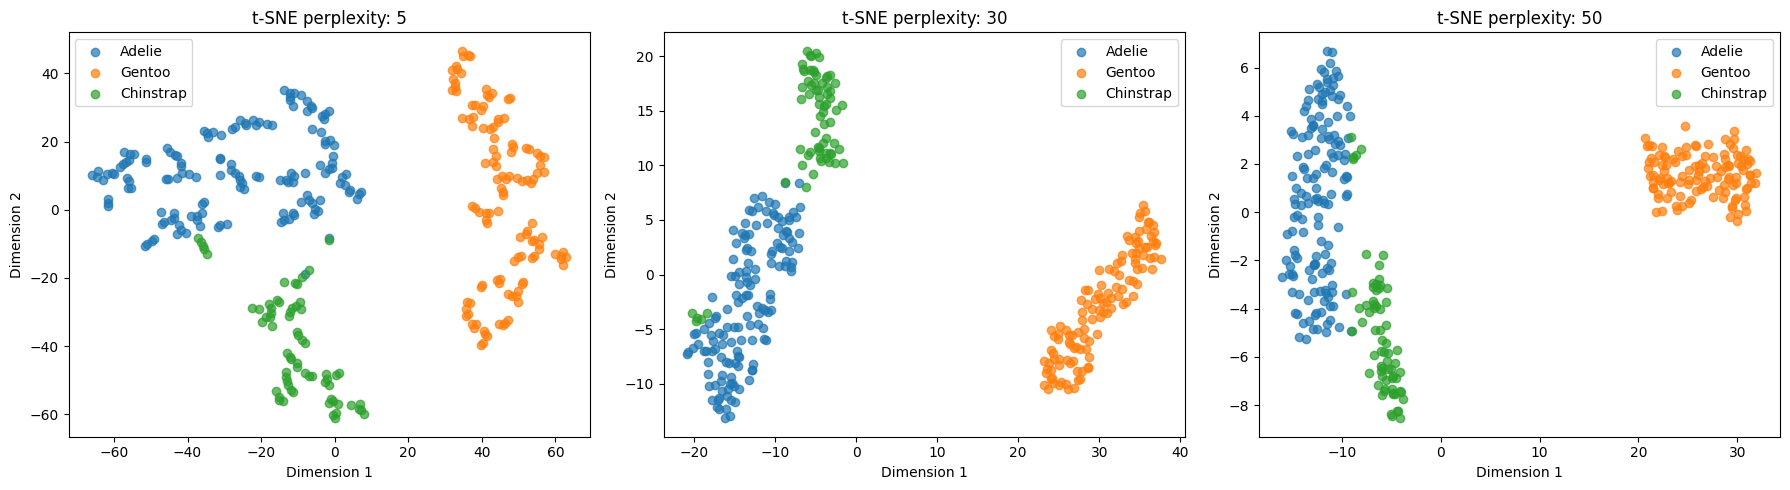

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


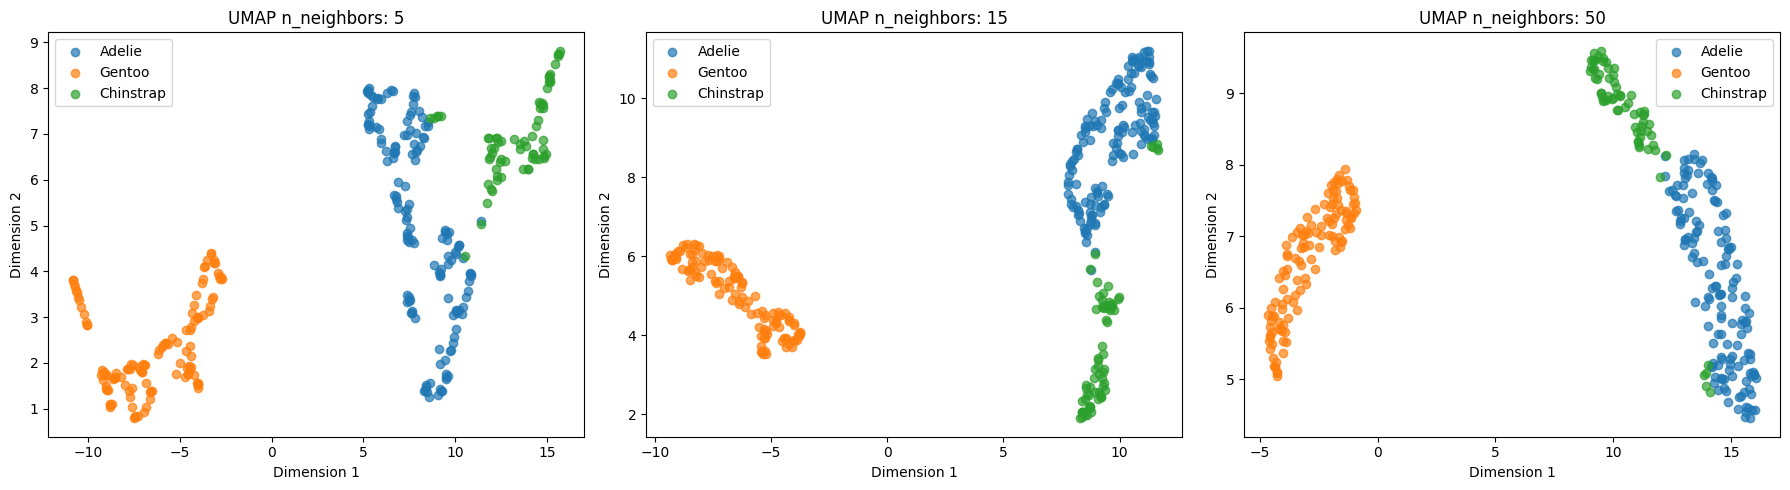

In [37]:
perplexity = [5, 30, 50]
n_neighbors = [5, 15, 50]

# t-SNE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, p in zip(axes, perplexity):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    tsne_data = tsne.fit_transform(scaled_penguin_data)

    for species in y.unique():
        mask = y == species
        ax.scatter(
            tsne_data[mask, 0],
            tsne_data[mask, 1],
            label=species,
            alpha=0.7
        )

    ax.set_title(f"t-SNE perplexity: {p}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.legend()

plt.tight_layout()
plt.show()

# UMAP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n in zip(axes, n_neighbors):
    umap_model = UMAP(n_components=2, n_neighbors=n, random_state=42)
    umap_data = umap_model.fit_transform(scaled_penguin_data)

    for species in y.unique():
        mask = y == species
        ax.scatter(
            umap_data[mask, 0],
            umap_data[mask, 1],
            label=species,
            alpha=0.7
        )

    ax.set_title(f"UMAP n_neighbors: {n}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.legend()

plt.tight_layout()
plt.show()

After generating the plots, describe the main changes you observe in the visualizations:
- How do the clusters shift, stretch, or separate as hyperparameters change?
- Which settings appear to better preserve the structure of the data?

Elaborate on your observations and support your discussion with specific visual examples.

t-sne:
- The clusters appear to get tighter as perplexity increases
- This could be because t-SNE is stochastic 

## 3. Apply to Real Data (1000 Genomes Subset) (25 points)

Your goal in this section is to try to create a figure similar to Figure 1 of the Diaz-Papkovich *et al.* (2019) paper, using a subset of genotype data from the 1000 Genomes Project.

To do so, complete the following steps:

a. Load the genotype dataset accompanying this lab, where each row corresponds to an individual, and each column to a genetic variant. Load also the provided population labels for each individual. 

b. **Standardize** the features (i.e., transform the genotype values to have zero mean and unit variance).

c. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the data to 2 dimensions. You may use the default values for the rest of hyperparameters in these techniques. 

d. Create **scatter plots** of the resulting projections, coloring each point according to its **population group**.

e. Reflect on the following questions:
- Explain what you observe in each case. Additionally, which method appears to provide the best visual separation of the population into distinct groups? Elaborate on why this might be the case, based on what you know about each method.
- What changes if you first reduce the data to the **top 25 PCA components**, and then apply t-SNE or UMAP?
- In your opinion, what are the trade-offs between **interpretability** (e.g., preservation of local and global structure) and **performance** (e.g., visual separation of known populations and computational time) when using these dimensionality reduction methods?

Please elaborate on your answers and use the plots to support your discussion.

In [38]:
# YOUR CODE HERE

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE